# Linear-reconstruction + residual U-Net (v_z)

Two-stage pipeline:

1. **Linear reconstruction** of v_z from the noisy Tb via the continuity equation
   `v_z(k) = i · a · H(z) · f(z) · (k_z / k²) · δ_Tb(k)` (same operator as
   `ksz_reconstruction/functions/generate_all_plots.py`). Gives a first v_z
   estimate with correct morphology but arbitrary amplitude → a scalar α is
   fit on the training set: α·v_z_linrec ≈ v_z_true.

2. **U-Net residual correction** on top of the linear prediction — the model
   learns `v_z_true − α·v_z_linrec(Tb_noisy)` from the noisy Tb. Final
   prediction = α·v_z_linrec + model-output (un-standardised).

Uses the same cubes as `ml_pipeline_demo.ipynb` — generates them via a
subprocess if missing.


In [1]:
import sys, pathlib, subprocess
PHD_ROOT = pathlib.Path().resolve().parents[2]   # .../PhD
sys.path.insert(0, str(PHD_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import torch

from noisy_reconstruction.code.ml.config     import DemoConfig
from noisy_reconstruction.code.ml.noise      import observe_Tb
from noisy_reconstruction.code.ml.linear_rec import reconstruct_vz_from_tb, fit_alpha
from noisy_reconstruction.code.ml.train      import train_residual, load_best_residual

cfg = DemoConfig()
cfg

DemoConfig(hii_dim=128, box_len=256.0, target_xHI=0.5, z_grid=(6.0, 7.0, 7.5, 8.0, 8.5, 9.0, 10.0), n_train=16, n_val=4, seed0=1000, survey='HERA', hera_hex_num=11, hera_split_core=True, hera_outriggers=2, hera_dish_size_m=14.0, hera_latitude_deg=-30.0, track_hours=6.0, time_per_day_hours=6.0, n_days=180, batch_size=1, epochs=40, lr=0.0002, base_channels=16, device='cuda', data_dir=PosixPath('/Users/jelte/Documents/PhD/noisy_reconstruction/data/cubes'), ckpt_dir=PosixPath('/Users/jelte/Documents/PhD/noisy_reconstruction/data/checkpoints'))

## 1. Load (or generate) the cubes


In [2]:
existing = sorted(cfg.data_dir.glob("sim_seed*.npz"))
need = cfg.n_total

if len(existing) < need:
    print(f"Have {len(existing)} / {need} cubes — launching 21cmFAST subprocess.")
    subprocess.run(
        [sys.executable, "-u", "-m", "noisy_reconstruction.code.ml.simulate"],
        cwd=PHD_ROOT, check=True,
    )
    existing = sorted(cfg.data_dir.glob("sim_seed*.npz"))
else:
    print(f"All {need} cubes already on disk.")

paths = {
    "train": existing[:cfg.n_train],
    "val":   existing[cfg.n_train:cfg.n_total],
    "z":     float(np.load(existing[0])["z"]),
}
print(f"z = {paths['z']:.3f}   train={len(paths['train'])}  val={len(paths['val'])}")

All 20 cubes already on disk.
z = 8.124   train=16  val=4


## 2. Inspect the linear reconstruction on one val cube

Linear operator applied to the noisy Tb gives a v_z estimate. Compare it
against the true v_z on a mid-LoS slice, and compute voxel-level
Pearson r — this is the **no-ML baseline**.


finding redundancies: 61075ants [00:00, 2826889.99ants/s]


alpha (this cube)                 : -4.516e-04
corr(v_z_true, v_z_linrec)        : r = -0.034   (morphology)
corr(v_z_true, alpha * v_z_linrec): r = +0.034   (same — scale-invariant)
RMSE (alpha-scaled, km/s)         : 1017.7


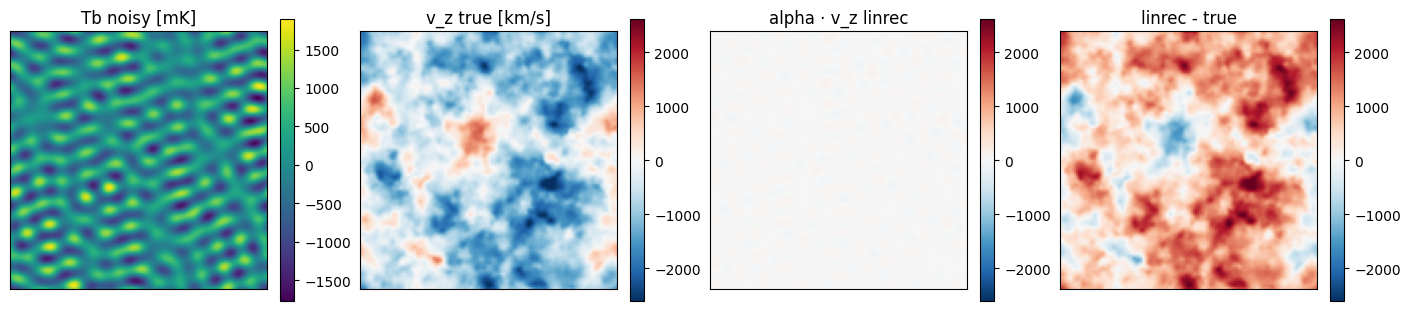

In [3]:
val = np.load(paths['val'][0])
Tb_signal = val['Tb']
vz_true   = val['vz']
z_used    = float(val['z'])
box_len   = float(val['box_len'])

Tb_noisy = observe_Tb(Tb_signal, z_used, cfg, seed=1234)
vz_lin   = reconstruct_vz_from_tb(Tb_noisy, z_used, box_len)

alpha_here = fit_alpha(vz_true, vz_lin)
vz_lin_scaled = alpha_here * vz_lin

r_lin  = float(np.corrcoef(vz_true.ravel(), vz_lin.ravel())[0,1])
r_scal = float(np.corrcoef(vz_true.ravel(), vz_lin_scaled.ravel())[0,1])
rmse   = float(np.sqrt(np.mean((vz_true - vz_lin_scaled)**2)))
print(f"alpha (this cube)                 : {alpha_here:+.3e}")
print(f"corr(v_z_true, v_z_linrec)        : r = {r_lin :+.3f}   (morphology)")
print(f"corr(v_z_true, alpha * v_z_linrec): r = {r_scal:+.3f}   (same — scale-invariant)")
print(f"RMSE (alpha-scaled, km/s)         : {rmse:.1f}")

mid  = cfg.hii_dim // 2
vmax = float(np.percentile(np.abs(vz_true), 99))
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), constrained_layout=True)
for ax, data, title, cmap, vm in [
    (axes[0], Tb_noisy[:, :, mid],       'Tb noisy [mK]',        'viridis', None),
    (axes[1], vz_true[:, :, mid],        'v_z true [km/s]',      'RdBu_r', vmax),
    (axes[2], vz_lin_scaled[:, :, mid],  'alpha · v_z linrec',   'RdBu_r', vmax),
    (axes[3], (vz_lin_scaled - vz_true)[:, :, mid], 'linrec - true', 'RdBu_r', vmax),
]:
    kw = dict(origin='lower', cmap=cmap)
    if vm is not None: kw.update(vmin=-vm, vmax=vm)
    im = ax.imshow(data.T, **kw)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.85)
plt.show()

## 3. Train the residual U-Net

Target: `v_z_true − α · v_z_linrec(Tb_noisy)` with α fit on the **training
set** (pooling all cubes). Checkpoints go to `<ckpt_dir>/linrec/` so they
don't collide with the direct-training run.


In [4]:
history = train_residual(cfg, paths['train'], paths['val'])

Fitting linear-reconstruction alpha on 16 train cubes ...


finding redundancies: 61075ants [00:00, 2575475.72ants/s]
finding redundancies: 61075ants [00:00, 2794967.07ants/s]
finding redundancies: 61075ants [00:00, 2696240.53ants/s]
finding redundancies: 61075ants [00:00, 659344.27ants/s]
finding redundancies: 61075ants [00:00, 2894674.53ants/s]
finding redundancies: 61075ants [00:00, 2833550.32ants/s]
finding redundancies: 61075ants [00:00, 2837033.65ants/s]
finding redundancies: 61075ants [00:00, 2880774.57ants/s]
finding redundancies: 61075ants [00:00, 2858497.55ants/s]
finding redundancies: 61075ants [00:00, 2822187.28ants/s]
finding redundancies: 61075ants [00:00, 2790461.07ants/s]
finding redundancies: 61075ants [00:00, 2845858.61ants/s]
finding redundancies: 61075ants [00:00, 2835683.24ants/s]
finding redundancies: 61075ants [00:00, 2760243.05ants/s]
finding redundancies: 61075ants [00:00, 2824396.53ants/s]
finding redundancies: 61075ants [00:00, 2878314.55ants/s]


  alpha = -5.045e-04
Computing residual-target normalisation stats ...


finding redundancies: 61075ants [00:00, 2499898.67ants/s]
finding redundancies: 61075ants [00:00, 2819609.00ants/s]
finding redundancies: 61075ants [00:00, 2834522.28ants/s]
finding redundancies: 61075ants [00:00, 2782187.34ants/s]
finding redundancies: 61075ants [00:00, 2767579.05ants/s]
finding redundancies: 61075ants [00:00, 2833048.92ants/s]
finding redundancies: 61075ants [00:00, 2771261.69ants/s]
finding redundancies: 61075ants [00:00, 2768207.10ants/s]
finding redundancies: 61075ants [00:00, 2721823.25ants/s]
finding redundancies: 61075ants [00:00, 1666160.10ants/s]
finding redundancies: 61075ants [00:00, 2789184.99ants/s]
finding redundancies: 61075ants [00:00, 2781432.12ants/s]
finding redundancies: 61075ants [00:00, 2516697.78ants/s]
finding redundancies: 61075ants [00:00, 2712025.88ants/s]
finding redundancies: 61075ants [00:00, 2737822.68ants/s]
finding redundancies: 61075ants [00:00, 2597069.22ants/s]


  x: mean=-0.000 std=597.251
  y: mean=0.000 std=1020.798  (residual target)
Using device: cpu
U-Net parameters: 5,646,385


...

epoch  37  train 0.6228  val 0.6964  r_resid=+0.550  lr=1.23e-06  (137.9s)


finding redundancies: 61075ants [00:00, 1700502.63ants/s]
finding redundancies: 61075ants [00:00, 1643687.91ants/s]
finding redundancies: 61075ants [00:00, 1706290.62ants/s]
finding redundancies: 61075ants [00:00, 1718769.44ants/s]
finding redundancies: 61075ants [00:00, 1730473.05ants/s]
finding redundancies: 61075ants [00:00, 1733165.88ants/s]
finding redundancies: 61075ants [00:00, 1671498.13ants/s]
finding redundancies: 61075ants [00:00, 1605459.49ants/s]
finding redundancies: 61075ants [00:00, 1690894.38ants/s]
finding redundancies: 61075ants [00:00, 1688375.71ants/s]
finding redundancies: 61075ants [00:00, 1709148.10ants/s]
finding redundancies: 61075ants [00:00, 1738588.57ants/s]
finding redundancies: 61075ants [00:00, 1701541.79ants/s]
finding redundancies: 61075ants [00:00, 1720616.58ants/s]
finding redundancies: 61075ants [00:00, 1720189.08ants/s]
finding redundancies: 61075ants [00:00, 1736020.04ants/s]
finding redundancies: 61075ants [00:00, 1715580.95ants/s]
finding redund

epoch  38  train 0.6222  val 0.6691  r_resid=+0.574  lr=3.08e-07  (139.6s)


finding redundancies: 61075ants [00:00, 1699025.14ants/s]
finding redundancies: 61075ants [00:00, 1654666.00ants/s]
finding redundancies: 61075ants [00:00, 1705154.84ants/s]
finding redundancies: 61075ants [00:00, 1720674.37ants/s]
finding redundancies: 61075ants [00:00, 1728756.36ants/s]
finding redundancies: 61075ants [00:00, 1669308.78ants/s]
finding redundancies: 61075ants [00:00, 1728744.69ants/s]
finding redundancies: 61075ants [00:00, 1688843.22ants/s]
finding redundancies: 61075ants [00:00, 1718780.98ants/s]
finding redundancies: 61075ants [00:00, 1693230.29ants/s]
finding redundancies: 61075ants [00:00, 1676958.29ants/s]
finding redundancies: 61075ants [00:00, 1711157.46ants/s]
finding redundancies: 61075ants [00:00, 274741.57ants/s]
finding redundancies: 61075ants [00:00, 1625539.33ants/s]
finding redundancies: 61075ants [00:00, 1715213.37ants/s]
finding redundancies: 61075ants [00:00, 1702480.39ants/s]
finding redundancies: 61075ants [00:00, 1663898.24ants/s]
finding redunda

epoch  39  train 0.6388  val 0.6850  r_resid=+0.562  lr=0.00e+00  (135.1s)
done.  best residual r = +0.574


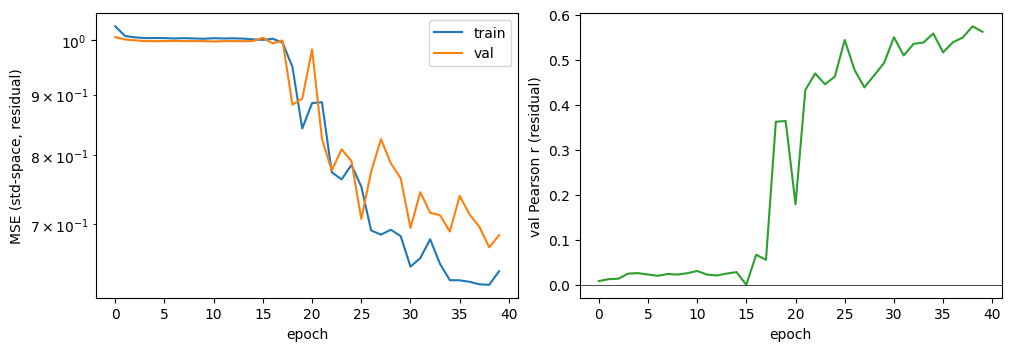

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), constrained_layout=True)
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val')
axes[0].set_yscale('log'); axes[0].set_xlabel('epoch'); axes[0].set_ylabel('MSE (std-space, residual)')
axes[0].legend()
axes[1].plot(history['val_r_resid'], color='C2')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val Pearson r (residual)')
axes[1].axhline(0, color='k', lw=0.5)
plt.show()

## 4. Evaluate: linear-only vs. linear + U-Net residual

Both are evaluated on the same noisy Tb realisation per val cube.


In [6]:
model, stats, alpha, device = load_best_residual(cfg)
print(f"loaded best.  alpha = {alpha:+.3e}   device = {device}")

rows = []
preds_full = {}
for p in paths['val']:
    d = np.load(p)
    z_v  = float(d['z']); bl = float(d['box_len'])
    Tb_n = observe_Tb(d['Tb'], z_v, cfg, seed=999)
    vz_t = d['vz']
    vz_l = reconstruct_vz_from_tb(Tb_n, z_v, bl)

    x = ((Tb_n - stats.x_mean) / stats.x_std).astype(np.float32)
    xt = torch.from_numpy(x).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_resid = model(xt).squeeze().cpu().numpy() * stats.y_std + stats.y_mean
    vz_full = alpha * vz_l + pred_resid

    r_lin  = float(np.corrcoef(vz_t.ravel(), (alpha*vz_l).ravel())[0, 1])
    r_full = float(np.corrcoef(vz_t.ravel(),  vz_full.ravel())[0, 1])
    rows.append((p.name, r_lin, r_full))
    preds_full[p.name] = (vz_t, alpha*vz_l, vz_full)

print(f"{'cube':<22} {'r_linear':>10} {'r_linear+U-Net':>16}")
for name, r1, r2 in rows:
    print(f"{name:<22} {r1:>+10.3f} {r2:>+16.3f}")

loaded best.  alpha = -5.045e-04   device = cpu


finding redundancies: 61075ants [00:00, 1633677.18ants/s]
finding redundancies: 61075ants [00:00, 1716259.10ants/s]
finding redundancies: 61075ants [00:00, 1718193.03ants/s]
finding redundancies: 61075ants [00:00, 1745304.83ants/s]


cube                     r_linear   r_linear+U-Net
sim_seed1016.npz           +0.035           +0.438
sim_seed1017.npz           +0.038           +0.565
sim_seed1018.npz           +0.037           +0.401
sim_seed1019.npz           +0.049           +0.626


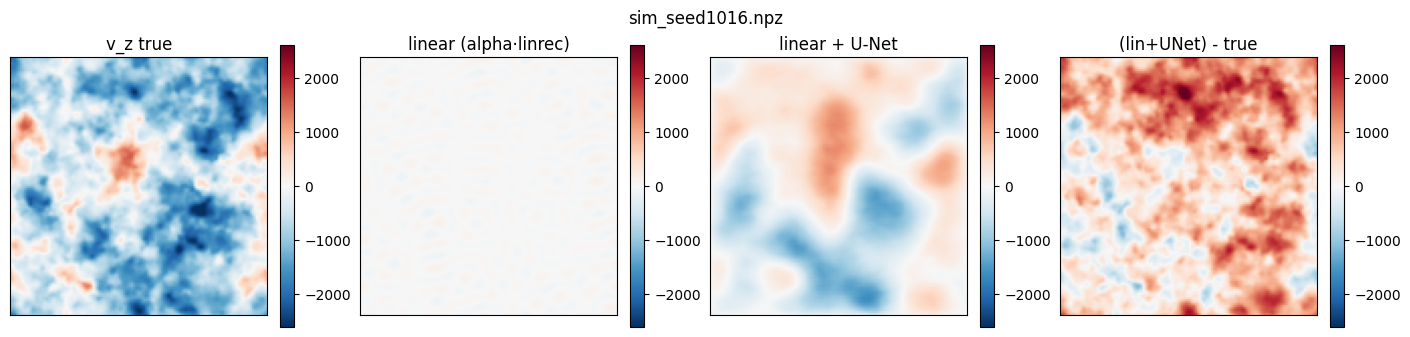

In [7]:
name = paths['val'][0].name
vz_t, vz_lin_s, vz_full = preds_full[name]

mid  = cfg.hii_dim // 2
vmax = float(np.percentile(np.abs(vz_t), 99))
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), constrained_layout=True)
for ax, data, title in [
    (axes[0], vz_t[:, :, mid],             'v_z true'),
    (axes[1], vz_lin_s[:, :, mid],         'linear (alpha·linrec)'),
    (axes[2], vz_full[:, :, mid],          'linear + U-Net'),
    (axes[3], (vz_full - vz_t)[:, :, mid], '(lin+UNet) - true'),
]:
    im = ax.imshow(data.T, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.85)
plt.suptitle(name, y=1.02)
plt.show()

### Voxel scatter: true vs predicted (subsampled)


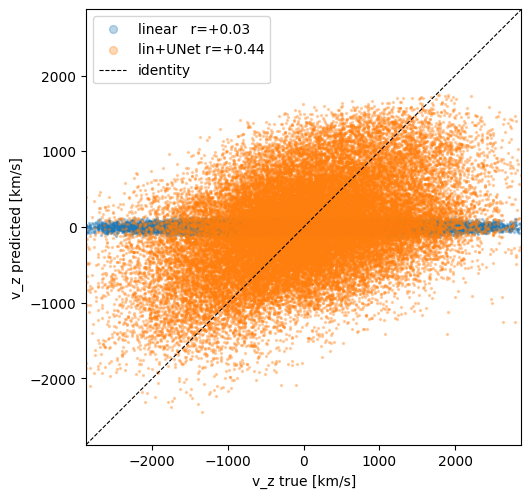

In [8]:
rng = np.random.default_rng(0)
N = vz_t.size
idx = rng.choice(N, size=min(N, 40_000), replace=False)

plt.figure(figsize=(5.4, 5.4))
plt.scatter(vz_t.ravel()[idx],     vz_lin_s.ravel()[idx], s=2, alpha=0.3, label=f"linear   r={np.corrcoef(vz_t.ravel(), vz_lin_s.ravel())[0,1]:+.2f}")
plt.scatter(vz_t.ravel()[idx],     vz_full.ravel()[idx],  s=2, alpha=0.3, label=f"lin+UNet r={np.corrcoef(vz_t.ravel(), vz_full.ravel())[0,1]:+.2f}")
lim = float(np.percentile(np.abs(vz_t), 99.5))
plt.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, label='identity')
plt.xlim(-lim, lim); plt.ylim(-lim, lim)
plt.xlabel('v_z true [km/s]'); plt.ylabel('v_z predicted [km/s]')
plt.legend(markerscale=4); plt.gca().set_aspect('equal')
plt.tight_layout(); plt.show()

### 1D power-spectrum comparison


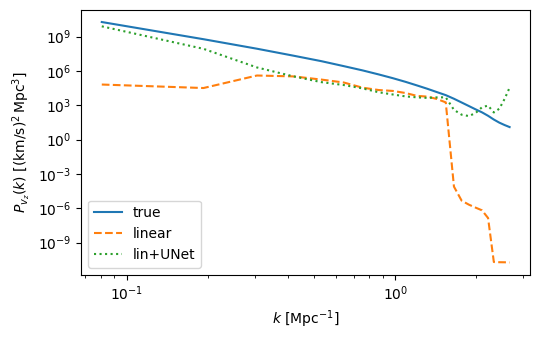

In [9]:
def _power_1d(cube, box_len):
    n = cube.shape[0]
    k1 = np.fft.fftfreq(n, d=box_len / n) * 2 * np.pi
    kx, ky, kz = np.meshgrid(k1, k1, k1, indexing='ij')
    kmag = np.sqrt(kx**2 + ky**2 + kz**2)
    fft  = np.fft.fftn(cube - cube.mean())
    pk3  = (np.abs(fft)**2) * (box_len / n)**3 / (n**3)
    bins = np.linspace(kmag[kmag > 0].min(), kmag.max(), 25)
    k_c  = 0.5 * (bins[1:] + bins[:-1])
    idx  = np.digitize(kmag.ravel(), bins)
    pk1  = np.array([pk3.ravel()[idx == i].mean() if np.any(idx == i) else np.nan
                     for i in range(1, len(bins))])
    return k_c, pk1

k,  pk_t = _power_1d(vz_t,     cfg.box_len)
_,  pk_l = _power_1d(vz_lin_s, cfg.box_len)
_,  pk_u = _power_1d(vz_full,  cfg.box_len)

plt.figure(figsize=(5.5, 3.5))
plt.loglog(k, pk_t, label='true')
plt.loglog(k, pk_l, label='linear',   ls='--')
plt.loglog(k, pk_u, label='lin+UNet', ls=':')
plt.xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P_{v_z}(k)\ [(\mathrm{km/s})^2\,\mathrm{Mpc}^3]$')
plt.legend(); plt.tight_layout(); plt.show()